<a href="https://colab.research.google.com/github/yana-g/graph-analysis/blob/main/03_Community_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3. Community Analysis of the Israeli Actors Collaboration Graph

This notebook detects and analyzes communities in the actor collaboration network for **1990–Today**.

The analysis:

1. Builds the Period C collaboration graph.
2. Compares Louvain and Label Propagation.
3. Selects the partition with the highest modularity.
4. Examines community sizes and central actors.
5. Characterizes the largest communities using genres, recurring directors, and activity periods.
6. Documents the limits of cinematic-style and demographic interpretation.

### 1. Imports

In [1]:
from pathlib import Path
import itertools
import re
import time
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from networkx.algorithms.community import (
    louvain_communities,
    asyn_lpa_communities,
    modularity
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 100)

### 2. Load and Validate Data

The notebook uses the cleaned `movies_with_actors.csv` file created in Part 1.

In [2]:
DATA_FILE = Path(
    "movies_with_actors.csv"
)

START_YEAR = 1990

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Required input file not found: {DATA_FILE}"
    )

movies_df = pd.read_csv(
    DATA_FILE,
    encoding="utf-8-sig"
)

required_columns = {
    "page_id",
    "movie_title",
    "year",
    "genre",
    "director"
}

missing_columns = (
    required_columns
    - set(movies_df.columns)
)

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

movies_df["year"] = pd.to_numeric(
    movies_df["year"],
    errors="coerce"
)

movies_df = (
    movies_df
    .dropna(
        subset=[
            "page_id",
            "movie_title",
            "year"
        ]
    )
    .drop_duplicates(
        subset="page_id"
    )
    .copy()
)

movies_df["year"] = (
    movies_df["year"]
    .astype(int)
)

actor_columns = sorted(
    [
        column
        for column in movies_df.columns
        if re.fullmatch(r"actor_\d+", column)
    ],
    key=lambda column: int(
        column.split("_")[1]
    )
)

if not actor_columns:
    raise ValueError(
        "No actor columns matching actor_1, actor_2, ... were found."
    )

period_c_df = (
    movies_df[
        movies_df["year"].ge(
            START_YEAR
        )
    ]
    .copy()
)

print("All movies:", len(movies_df))
print("Period C movies:", len(period_c_df))
print(
    "Period C year range:",
    period_c_df["year"].min(),
    "-",
    period_c_df["year"].max()
)
print("Actor columns:", actor_columns)

All movies: 1155
Period C movies: 874
Period C year range: 1990 - 2026
Actor columns: ['actor_1', 'actor_2', 'actor_3', 'actor_4', 'actor_5', 'actor_6', 'actor_7', 'actor_8', 'actor_9', 'actor_10']


### 3. Metadata Quality Check

Missing values are reported before community characterization so that the results are interpreted in light of the available coverage.

In [3]:
genre_missing = (
    period_c_df["genre"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

director_missing = (
    period_c_df["director"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

metadata_quality_df = pd.DataFrame({
    "Field": [
        "Genre",
        "Director"
    ],
    "Available": [
        len(period_c_df) - genre_missing,
        len(period_c_df) - director_missing
    ],
    "Missing": [
        genre_missing,
        director_missing
    ]
})

metadata_quality_df["Coverage (%)"] = (
    metadata_quality_df["Available"]
    / len(period_c_df)
    * 100
).round(2)

display(metadata_quality_df)

,Field,Available,Missing,Coverage (%)
0,Genre,736,138,84.21
1,Director,865,9,98.97


### 4. Prepare Data

In [4]:
def clean_text(value):
    """Return a normalized string or an empty string."""
    if pd.isna(value):
        return ""

    return re.sub(
        r"\s+",
        " ",
        str(value)
    ).strip()


def get_movie_actors(row):
    """Return the unique actors listed for one movie."""
    actors = []
    seen = set()

    for column in actor_columns:
        actor = clean_text(
            row[column]
        )

        if not actor:
            continue

        key = actor.casefold()

        if key in seen:
            continue

        seen.add(key)
        actors.append(actor)

    return actors


def split_metadata(value):
    """Split pipe-separated metadata into unique cleaned values."""
    value = clean_text(value)

    if not value:
        return []

    result = []
    seen = set()

    for item in value.split("|"):
        item = clean_text(item)

        if not item:
            continue

        key = item.casefold()

        if key in seen:
            continue

        seen.add(key)
        result.append(item)

    return result

### 5. Build the Period C Graph

Each actor is a node. Two actors are connected when they appeared in the same film. Edge weight is the number of shared films.

In [5]:
def build_actor_graph(movies):
    """Build an undirected weighted actor collaboration graph."""
    graph = nx.Graph()

    for _, row in movies.iterrows():
        actors = get_movie_actors(
            row
        )

        graph.add_nodes_from(
            actors
        )

        for actor_1, actor_2 in itertools.combinations(
            actors,
            2
        ):
            if graph.has_edge(
                actor_1,
                actor_2
            ):
                graph[actor_1][actor_2]["weight"] += 1
                graph[actor_1][actor_2]["movies"].append(
                    row["movie_title"]
                )
                graph[actor_1][actor_2]["years"].append(
                    int(row["year"])
                )
            else:
                graph.add_edge(
                    actor_1,
                    actor_2,
                    weight=1,
                    movies=[row["movie_title"]],
                    years=[int(row["year"])]
                )

    return graph


G_period_c = build_actor_graph(
    period_c_df
)

print("Nodes:", G_period_c.number_of_nodes())
print("Edges:", G_period_c.number_of_edges())
print(
    "Connected components:",
    nx.number_connected_components(
        G_period_c
    )
)
print(
    "Isolated actors:",
    nx.number_of_isolates(
        G_period_c
    )
)

Nodes: 2537
Edges: 19304
Connected components: 60
Isolated actors: 18


### 6. Compare Community-Detection Algorithms

Louvain and Label Propagation are compared using:

- Number of communities
- Number of singleton communities
- Largest and average community size
- Weighted modularity
- Runtime

A higher modularity value indicates a stronger division into internally dense communities.

In [6]:
def run_community_algorithm(
    graph,
    algorithm_name,
    algorithm_function
):
    """Run one community algorithm and summarize its partition."""
    start_time = time.perf_counter()

    communities = [
        set(community)
        for community in algorithm_function(
            graph
        )
    ]

    runtime = (
        time.perf_counter()
        - start_time
    )

    sizes = [
        len(community)
        for community in communities
    ]

    score = modularity(
        graph,
        communities,
        weight="weight"
    )

    return {
        "algorithm": algorithm_name,
        "communities": communities,
        "community_count": len(communities),
        "singleton_communities": sum(
            size == 1
            for size in sizes
        ),
        "largest_community": max(sizes),
        "smallest_community": min(sizes),
        "average_size": float(
            np.mean(sizes)
        ),
        "median_size": float(
            np.median(sizes)
        ),
        "modularity": float(score),
        "runtime_seconds": float(runtime)
    }


algorithm_results = [
    run_community_algorithm(
        G_period_c,
        "Louvain",
        lambda graph: louvain_communities(
            graph,
            weight="weight",
            seed=42
        )
    ),
    run_community_algorithm(
        G_period_c,
        "Label Propagation",
        lambda graph: asyn_lpa_communities(
            graph,
            weight="weight",
            seed=42
        )
    )
]

comparison_df = pd.DataFrame([
    {
        "Algorithm": result["algorithm"],
        "Communities": result["community_count"],
        "Singleton Communities": result["singleton_communities"],
        "Largest Community": result["largest_community"],
        "Smallest Community": result["smallest_community"],
        "Average Size": result["average_size"],
        "Median Size": result["median_size"],
        "Modularity": result["modularity"],
        "Runtime (seconds)": result["runtime_seconds"]
    }
    for result in algorithm_results
])

comparison_df = (
    comparison_df
    .sort_values(
        "Modularity",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    comparison_df.style.format({
        "Average Size": "{:.2f}",
        "Median Size": "{:.2f}",
        "Modularity": "{:.4f}",
        "Runtime (seconds)": "{:.3f}"
    })
)

,Algorithm,Communities,Singleton Communities,Largest Community,Smallest Community,Average Size,Median Size,Modularity,Runtime (seconds)
0,Louvain,85,18,297,1,29.85,5.00,0.4723,0.577
1,Label Propagation,162,18,1738,1,15.66,5.00,0.1919,0.313


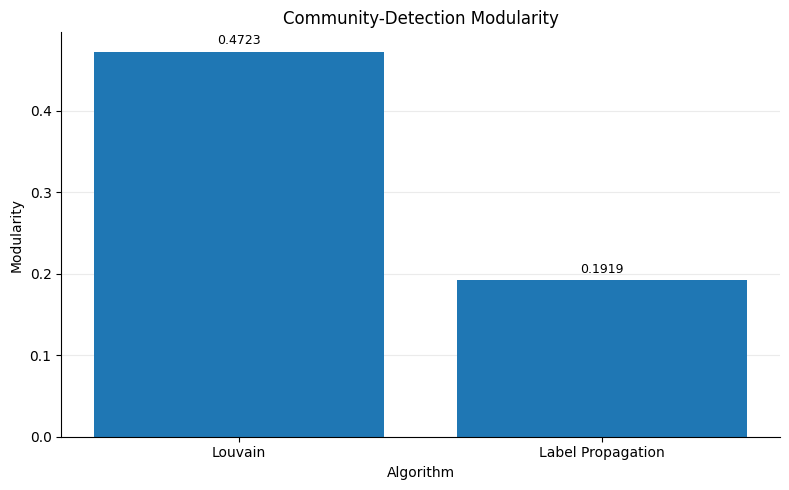

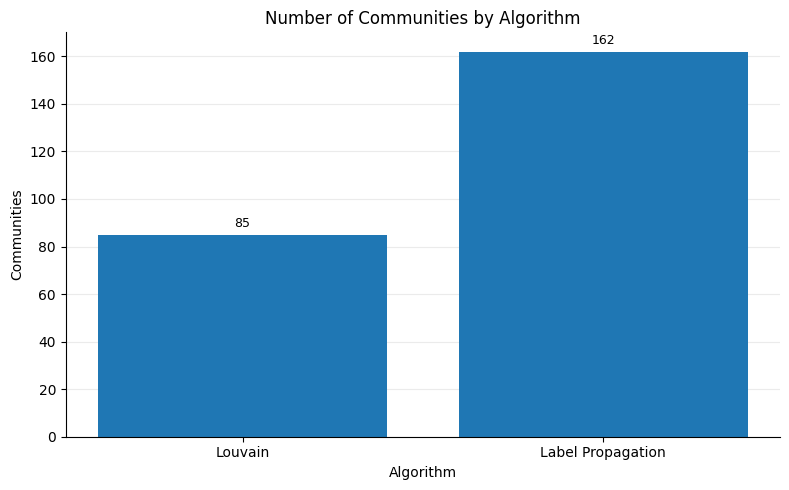

In [7]:
for column, title, ylabel, decimals in [
    (
        "Modularity",
        "Community-Detection Modularity",
        "Modularity",
        4
    ),
    (
        "Communities",
        "Number of Communities by Algorithm",
        "Communities",
        0
    )
]:
    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    plot_data = comparison_df[
        [
            "Algorithm",
            column
        ]
    ]

    bars = ax.bar(
        plot_data["Algorithm"],
        plot_data[column]
    )

    labels = [
        f"{value:.{decimals}f}"
        for value in plot_data[column]
    ]

    ax.bar_label(
        bars,
        labels=labels,
        padding=3,
        fontsize=9
    )

    ax.set_title(title)
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

### 7. Select the Best Partition

In [8]:
best_result = max(
    algorithm_results,
    key=lambda result: result["modularity"]
)

best_algorithm = best_result["algorithm"]

communities = sorted(
    best_result["communities"],
    key=len,
    reverse=True
)

print("Selected algorithm:", best_algorithm)
print(
    "Modularity:",
    f"{best_result['modularity']:.4f}"
)
print(
    "Number of communities:",
    len(communities)
)

Selected algorithm: Louvain
Modularity: 0.4723
Number of communities: 85


### 8. Assign Community Labels

In [9]:
actor_to_community = {}

for community_id, community in enumerate(
    communities,
    start=1
):
    for actor in community:
        actor_to_community[actor] = (
            community_id
        )

nx.set_node_attributes(
    G_period_c,
    actor_to_community,
    "community"
)

community_sizes_df = pd.DataFrame({
    "Community": range(
        1,
        len(communities) + 1
    ),
    "Size": [
        len(community)
        for community in communities
    ]
})

community_sizes_df.head(20)

,Community,Size
0,1,297
1,2,183
2,3,156
3,4,147
4,5,142
5,6,142
6,7,125
7,8,107
8,9,96
9,10,93


### 9. Community Sizes

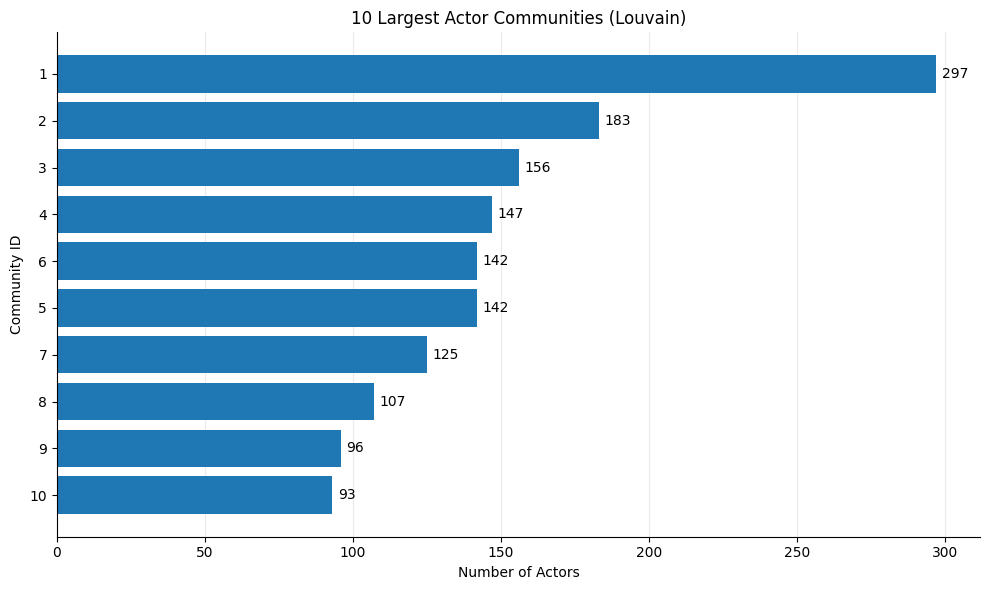

In [10]:
TOP_N_COMMUNITIES = 10

top_sizes = (
    community_sizes_df
    .head(TOP_N_COMMUNITIES)
    .sort_values(
        "Size",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.barh(
    top_sizes["Community"].astype(str),
    top_sizes["Size"]
)

ax.bar_label(
    bars,
    padding=4,
    fontsize=10
)

ax.set_title(
    f"10 Largest Actor Communities ({best_algorithm})"
)
ax.set_xlabel("Number of Actors")
ax.set_ylabel("Community ID")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

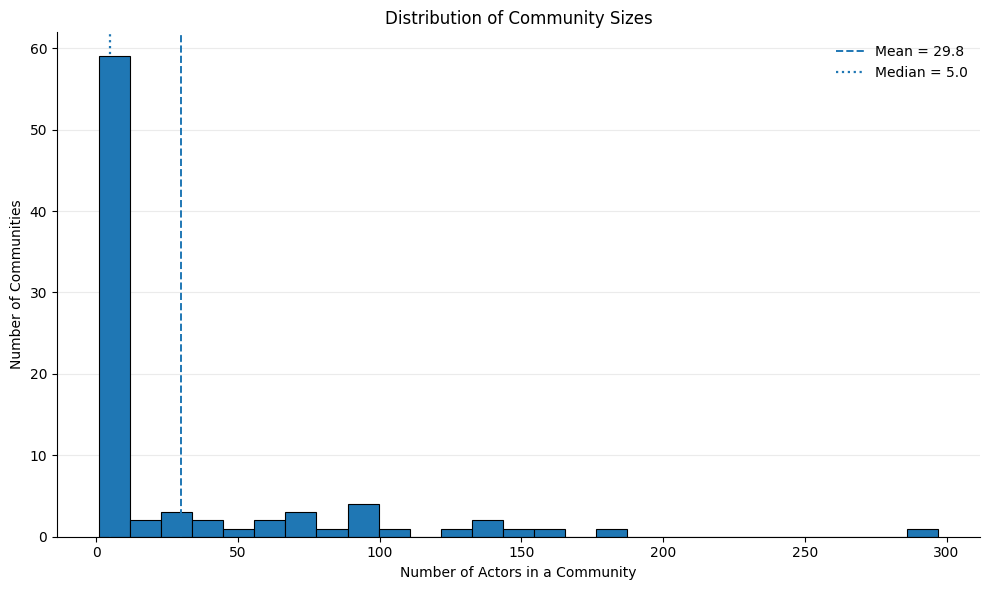

In [11]:
community_sizes = (
    community_sizes_df["Size"]
    .to_numpy()
)

q1, q3 = np.percentile(
    community_sizes,
    [25, 75]
)

iqr = q3 - q1

if iqr > 0:
    bin_width = (
        2
        * iqr
        / np.cbrt(
            len(community_sizes)
        )
    )

    number_of_bins = max(
        5,
        int(np.ceil(
            (
                community_sizes.max()
                - community_sizes.min()
            )
            / bin_width
        ))
    )
else:
    number_of_bins = 10

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    community_sizes,
    bins=number_of_bins,
    edgecolor="black",
    linewidth=0.8
)

ax.axvline(
    community_sizes.mean(),
    linestyle="--",
    linewidth=1.4,
    label=f"Mean = {community_sizes.mean():.1f}"
)

ax.axvline(
    np.median(community_sizes),
    linestyle=":",
    linewidth=1.6,
    label=f"Median = {np.median(community_sizes):.1f}"
)

ax.set_title(
    "Distribution of Community Sizes"
)
ax.set_xlabel(
    "Number of Actors in a Community"
)
ax.set_ylabel(
    "Number of Communities"
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### 10. Community Network Visualization

All calculations use the complete graph. For readability, the figure displays the 10 largest communities and up to 25 of the most connected actors from each community.

- Node color represents community membership.
- Node size represents weighted degree in the full network.
- Edge width represents the number of shared films.

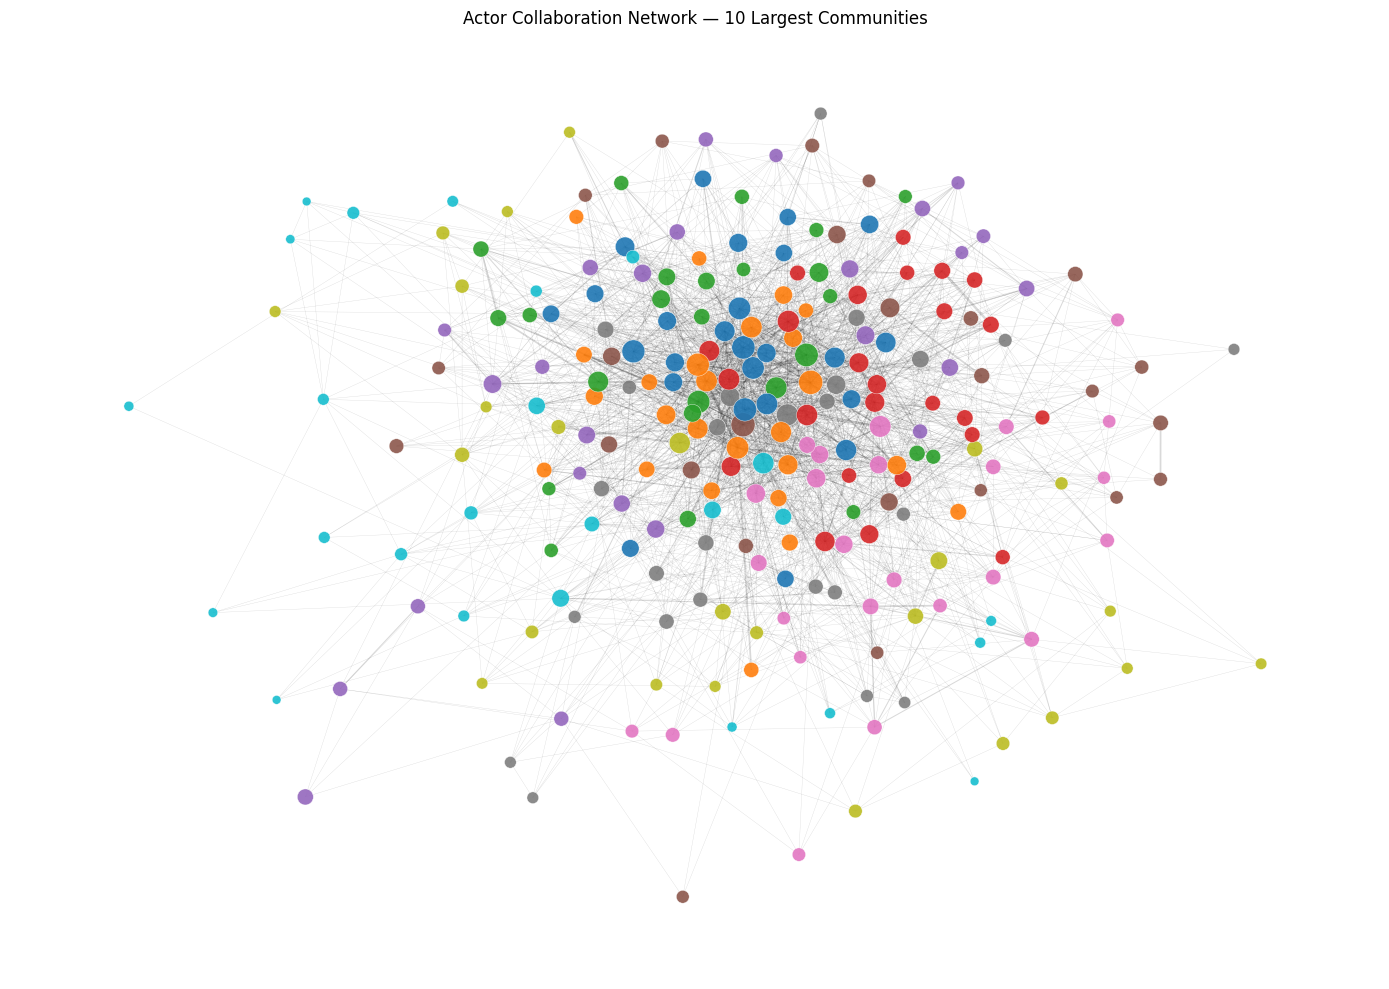

Displayed nodes: 250
Displayed edges: 2472


In [12]:
TOP_COMMUNITIES_FOR_NETWORK = 10
MAX_ACTORS_PER_COMMUNITY = 25
LAYOUT_SEED = 42

largest_community_ids = (
    community_sizes_df
    .head(
        TOP_COMMUNITIES_FOR_NETWORK
    )["Community"]
    .tolist()
)

full_weighted_degree = dict(
    G_period_c.degree(
        weight="weight"
    )
)

selected_nodes = []

for community_id in largest_community_ids:
    community_nodes = [
        actor
        for actor, assigned_id
        in actor_to_community.items()
        if assigned_id == community_id
    ]

    community_nodes = sorted(
        community_nodes,
        key=lambda actor: full_weighted_degree.get(
            actor,
            0
        ),
        reverse=True
    )[:MAX_ACTORS_PER_COMMUNITY]

    selected_nodes.extend(
        community_nodes
    )

network_view = G_period_c.subgraph(
    selected_nodes
).copy()

positions = nx.spring_layout(
    network_view,
    weight="weight",
    seed=LAYOUT_SEED,
    k=0.35,
    iterations=150
)

community_order = {
    community_id: index
    for index, community_id
    in enumerate(
        largest_community_ids
    )
}

node_values = [
    community_order[
        actor_to_community[node]
    ]
    for node in network_view.nodes()
]

node_degrees = np.array([
    full_weighted_degree.get(
        node,
        0
    )
    for node in network_view.nodes()
], dtype=float)

if (
    len(node_degrees) > 0
    and node_degrees.max()
    > node_degrees.min()
):
    node_sizes = (
        40
        + 260
        * (
            (
                np.sqrt(node_degrees)
                - np.sqrt(
                    node_degrees.min()
                )
            )
            / (
                np.sqrt(
                    node_degrees.max()
                )
                - np.sqrt(
                    node_degrees.min()
                )
            )
        )
    )
else:
    node_sizes = np.full(
        len(node_degrees),
        80.0
    )

edge_weights = np.array([
    network_view[u][v].get(
        "weight",
        1
    )
    for u, v
    in network_view.edges()
], dtype=float)

if (
    len(edge_weights) > 0
    and edge_weights.max()
    > edge_weights.min()
):
    edge_widths = (
        0.25
        + 1.5
        * (
            (
                edge_weights
                - edge_weights.min()
            )
            / (
                edge_weights.max()
                - edge_weights.min()
            )
        )
    )
else:
    edge_widths = np.full(
        len(edge_weights),
        0.6
    )

fig, ax = plt.subplots(
    figsize=(14, 10)
)

nx.draw_networkx_edges(
    network_view,
    positions,
    ax=ax,
    width=edge_widths,
    alpha=0.15
)

nx.draw_networkx_nodes(
    network_view,
    positions,
    ax=ax,
    node_color=node_values,
    node_size=node_sizes,
    cmap=plt.cm.tab10,
    linewidths=0.3,
    edgecolors="white",
    alpha=0.9
)

ax.set_title(
    "Actor Collaboration Network — 10 Largest Communities"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()

print(
    "Displayed nodes:",
    network_view.number_of_nodes()
)
print(
    "Displayed edges:",
    network_view.number_of_edges()
)

### 11. Central Actors in the Largest Communities

In [13]:
def get_top_actors_in_community(
    graph,
    community,
    top_n=5
):
    """Rank actors by their internal and global collaboration degrees."""
    subgraph = graph.subgraph(
        community
    )

    internal_degree = dict(
        subgraph.degree()
    )

    weighted_internal_degree = dict(
        subgraph.degree(
            weight="weight"
        )
    )

    rows = []

    for actor in community:
        rows.append({
            "Actor": actor,
            "Internal Degree": internal_degree.get(
                actor,
                0
            ),
            "Weighted Internal Degree": weighted_internal_degree.get(
                actor,
                0
            ),
            "Global Degree": graph.degree(
                actor
            )
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            [
                "Internal Degree",
                "Weighted Internal Degree",
                "Global Degree"
            ],
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )


TOP_COMMUNITIES = 10
TOP_ACTORS = 5

central_actor_records = []

for community_id, community in enumerate(
    communities[:TOP_COMMUNITIES],
    start=1
):
    table = get_top_actors_in_community(
        G_period_c,
        community,
        top_n=TOP_ACTORS
    )

    table.insert(
        0,
        "Community",
        community_id
    )

    table.insert(
        1,
        "Community Size",
        len(community)
    )

    central_actor_records.append(
        table
    )

central_actors_df = pd.concat(
    central_actor_records,
    ignore_index=True
)

for community_id in range(
    1,
    TOP_COMMUNITIES + 1
):
    display(
        central_actors_df[
            central_actors_df["Community"]
            .eq(community_id)
        ]
    )

,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
0,1,297,אסי דיין,58,73,129
1,1,297,אלברט אילוז,50,54,137
2,1,297,שרון אלכסנדר,45,51,123
3,1,297,שמיל בן ארי,41,54,136
4,1,297,עמוס לביא,40,47,117


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
5,2,183,מוני מושונוב,63,83,111
6,2,183,ליאור אשכנזי,38,45,137
7,2,183,מיכאל מושונוב,38,44,80
8,2,183,מנשה נוי,37,50,99
9,2,183,צחי גראד,37,44,160


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
10,3,156,יגאל עדיקא,47,61,125
11,3,156,אורי גבריאל,37,44,144
12,3,156,אריה מוסקונה,37,44,92
13,3,156,זאב רווח,31,35,66
14,3,156,גבי עמרני,31,34,60


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
15,4,147,לבנה פינקלשטיין,43,53,114
16,4,147,צחי הלוי,36,44,72
17,4,147,ששון גבאי,31,38,104
18,4,147,אוולין הגואל,28,36,77
19,4,147,עפר שכטר,28,34,69


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
20,5,142,מיכל ינאי,31,33,66
21,5,142,נאיה פדרמן,29,33,32
22,5,142,אורי הוכמן,27,29,71
23,5,142,מאיר סוויסה,26,26,44
24,5,142,יובל שם-טוב,24,25,35


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
25,6,142,מכרם ח'ורי,33,36,60
26,6,142,רוברט הניג,24,27,37
27,6,142,שרית וינו אלעד,22,22,52
28,6,142,מילי עשת,22,22,38
29,6,142,אלון אבוטבול,18,21,162


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
30,7,125,אדיר מילר,33,34,39
31,7,125,גורי אלפי,25,25,42
32,7,125,תובל שפיר,24,28,33
33,7,125,ג'וי ריגר,24,24,63
34,7,125,דניאל ליטמן,20,20,23


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
35,8,107,ולדימיר פרידמן,30,31,117
36,8,107,ציון ברוך,26,33,79
37,8,107,שלום מיכאלשווילי,25,30,30
38,8,107,רועי ניק,24,24,38
39,8,107,דוד שאול,18,22,32


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
40,9,96,אייל רוזלס,28,30,107
41,9,96,יואב לוי,24,25,58
42,9,96,דניאלה קרטס,18,18,27
43,9,96,אדריאנו חאובל,17,17,17
44,9,96,קרן ברגר,16,16,47


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
45,10,93,שרה אדלר,29,29,55
46,10,93,יחזקאל לזרוב,21,22,104
47,10,93,גרא סנדלר,19,19,51
48,10,93,יהודה אלמגור,17,17,22
49,10,93,גפן ברקאי,17,17,18


### 12. Associate Movies with Communities

A movie may contain actors from several communities.  
For community characterization, a movie is associated with every community represented by at least two actors in its cast. If no community has two actors, the movie is associated with the community containing the largest number of its actors.

This avoids forcing every cross-community movie into only one community while still preventing a single incidental actor from dominating the metadata profile.


In [14]:
def movie_community_details(row):
    """Return community memberships and cross-community information."""
    actors = get_movie_actors(row)

    community_counts = Counter(
        actor_to_community[actor]
        for actor in actors
        if actor in actor_to_community
    )

    if not community_counts:
        return pd.Series({
            "primary_community": np.nan,
            "community_memberships": [],
            "communities_in_movie": 0,
            "cross_community": False
        })

    maximum_count = max(
        community_counts.values()
    )

    primary_community = min(
        community_id
        for community_id, count
        in community_counts.items()
        if count == maximum_count
    )

    represented_communities = sorted(
        community_id
        for community_id, count
        in community_counts.items()
        if count >= 2
    )

    if not represented_communities:
        represented_communities = [
            primary_community
        ]

    return pd.Series({
        "primary_community": primary_community,
        "community_memberships": represented_communities,
        "communities_in_movie": len(
            community_counts
        ),
        "cross_community": (
            len(community_counts) > 1
        )
    })


movie_community_data = period_c_df.apply(
    movie_community_details,
    axis=1
)

period_c_df = pd.concat(
    [
        period_c_df,
        movie_community_data
    ],
    axis=1
)


def activity_period_label(year):
    """Group a movie year into a decade-style activity period."""
    if year <= 1999:
        return "1990–1999"

    if year <= 2009:
        return "2000–2009"

    if year <= 2019:
        return "2010–2019"

    return "2020–Present"


period_c_df["activity_period"] = (
    period_c_df["year"]
    .apply(activity_period_label)
)


community_movie_df = (
    period_c_df
    .explode(
        "community_memberships"
    )
    .rename(
        columns={
            "community_memberships":
                "community"
        }
    )
)

community_movie_df["community"] = pd.to_numeric(
    community_movie_df["community"],
    errors="coerce"
)

community_movie_df = (
    community_movie_df
    .dropna(
        subset=["community"]
    )
    .copy()
)

community_movie_df["community"] = (
    community_movie_df["community"]
    .astype(int)
)

print(
    "Movies with at least one community association:",
    period_c_df[
        "community_memberships"
    ].map(bool).sum()
)

print(
    "Cross-community movies:",
    period_c_df["cross_community"].sum()
)

print(
    "Movie-community associations:",
    len(community_movie_df)
)


Movies with at least one community association: 729
Cross-community movies: 505
Movie-community associations: 895


### 13. Characterize Communities

In [15]:
def most_common_values(
    series,
    top_n=5
):
    """Return the most frequent pipe-separated metadata values."""
    counter = Counter()

    for value in series.dropna():
        counter.update(
            split_metadata(value)
        )

    return counter.most_common(
        top_n
    )


def format_common_values(values):
    """Convert value-frequency pairs into readable text."""
    if not values:
        return "Not available"

    return ", ".join(
        f"{value} ({count})"
        for value, count in values
    )


def activity_period_label(year):
    """Group a movie year into a decade-style activity period."""
    if year <= 1999:
        return "1990–1999"

    if year <= 2009:
        return "2000–2009"

    if year <= 2019:
        return "2010–2019"

    return "2020–Present"


period_c_df["activity_period"] = (
    period_c_df["year"]
    .apply(
        activity_period_label
    )
)


In [16]:
community_summary_rows = []

total_period_movies = len(
    period_c_df
)

for community_id, community in enumerate(
    communities,
    start=1
):
    community_movies = community_movie_df[
        community_movie_df["community"].eq(
            community_id
        )
    ].drop_duplicates(
        subset="page_id"
    )

    top_actors = get_top_actors_in_community(
        G_period_c,
        community,
        top_n=5
    )["Actor"].tolist()

    activity_counts = (
        community_movies["activity_period"]
        .value_counts()
    )

    main_activity_period = (
        activity_counts.index[0]
        if not activity_counts.empty
        else "Not available"
    )

    community_summary_rows.append({
        "Community": community_id,
        "Actors": len(community),
        "Associated Movies": len(community_movies),
        "Associated Movie Share (%)": round(
            len(community_movies)
            / total_period_movies
            * 100,
            2
        ),
        "Cross-Community Movies": int(
            community_movies["cross_community"]
            .sum()
        ),
        "Top Actors": ", ".join(
            top_actors
        ),
        "Dominant Genres": format_common_values(
            most_common_values(
                community_movies["genre"],
                top_n=5
            )
        ),
        "Dominant Directors": format_common_values(
            most_common_values(
                community_movies["director"],
                top_n=5
            )
        ),
        "Main Activity Period": main_activity_period,
        "Average Movie Year": (
            round(
                community_movies["year"].mean(),
                1
            )
            if not community_movies.empty
            else np.nan
        ),
        "First Movie Year": (
            int(
                community_movies["year"].min()
            )
            if not community_movies.empty
            else np.nan
        ),
        "Last Movie Year": (
            int(
                community_movies["year"].max()
            )
            if not community_movies.empty
            else np.nan
        )
    })

community_summary_df = (
    pd.DataFrame(
        community_summary_rows
    )
    .sort_values(
        [
            "Actors",
            "Associated Movies"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    community_summary_df
    .head(10)
    .style.set_properties(
        subset=[
            "Top Actors",
            "Dominant Genres",
            "Dominant Directors"
        ],
        **{
            "text-align": "left",
            "white-space": "normal"
        }
    )
)


,Community,Actors,Associated Movies,Associated Movie Share (%),Cross-Community Movies,Top Actors,Dominant Genres,Dominant Directors,Main Activity Period,Average Movie Year,First Movie Year,Last Movie Year
0,1,297,161,18.420000,140,"אסי דיין, אלברט אילוז, שרון אלכסנדר, שמיל בן ארי, עמוס לביא","דרמה (106), קומדיה (12), דרמה קומית (4), להט""בי (3), עצמאי (2)","חיים בוזגלו (6), דורון ערן (5), אסי דיין (5), אורי ברבש (4), מיכל בת-אדם (4)",2000–2009,2005.400000,1990,2025
1,2,183,99,11.330000,92,"מוני מושונוב, ליאור אשכנזי, מיכאל מושונוב, מנשה נוי, צחי גראד","דרמה (54), קומדיה (20), דרמה קומית (7), פשע (4), להט""בי (4)","צבי שיסל (3), איתן גרין (3), יוסף פיצ'חדזה (3), עמוס גיתאי (3), עודד דוידוף (3)",2000–2009,2008.100000,1990,2025
2,3,156,66,7.550000,59,"יגאל עדיקא, אורי גבריאל, אריה מוסקונה, זאב רווח, גבי עמרני","דרמה (33), קומדיה (8), דרמה קומית (4), מוזיקלי (2), תיעודי (2)","ארנון צדוק (4), אריק לובצקי (4), ערן ריקליס (3), אורי ענבר (3), מתי הררי (3)",1990–1999,2003.000000,1990,2025
3,4,147,78,8.920000,71,"לבנה פינקלשטיין, צחי הלוי, ששון גבאי, אוולין הגואל, עפר שכטר","דרמה (36), קומדיה (21), אקשן (3), דרמה קומית (3), מתח (2)","שמי זרחין (5), ארז תדמור (5), שי כנות (3), שלום אסייג (3), אמיל בן שמעון (2)",2010–2019,2012.800000,1990,2026
4,6,142,52,5.950000,38,"מכרם ח'ורי, רוברט הניג, שרית וינו אלעד, מילי עשת, אלון אבוטבול","דרמה (35), קומדיה (4), סטודנטים (2), רומנטי (2), תיעודי (2)","טומי לנג (6), שבי גביזון (2), ערן ריקליס (2), גור בנטביץ' (1), שמי זרחין (1)",2000–2009,2011.800000,1995,2025
5,5,142,44,5.030000,35,"מיכל ינאי, נאיה פדרמן, אורי הוכמן, מאיר סוויסה, יובל שם-טוב","דרמה (13), קומדיה (12), מוזיקלי (5), הרפתקאות (5), קומי (3)","קובי מחט (5), צחי גראד (3), עמית אולמן (2), מנשה נוי (1), אורון אדר (1)",2010–2019,2013.200000,1997,2026
6,7,125,40,4.580000,32,"אדיר מילר, גורי אלפי, תובל שפיר, ג'וי ריגר, דניאל ליטמן","דרמה (21), קומדיה (10), נעורים (4), להט""בי (2), אימה (2)","אבי נשר (6), מתי הררי (3), דרור שאול (1), שמואל הספרי (1), אמיר הספרי (1)",2020–Present,2017.600000,2003,2026
7,8,107,41,4.690000,32,"ולדימיר פרידמן, ציון ברוך, שלום מיכאלשווילי, רועי ניק, דוד שאול","דרמה (19), קומדיה (9), פעולה (4), רומנטי (2), תיעודי (2)","יבגני רומן (3), איתן פוקס (2), בן בכר (2), שבי גביזון (1), עירית לינור (1)",2010–2019,2010.900000,1995,2025
8,9,96,22,2.520000,16,"אייל רוזלס, יואב לוי, דניאלה קרטס, אדריאנו חאובל, קרן ברגר","דרמה (13), עצמאי (3), להט""בי (1), מותחן פוליטי (1), קומדיה רומנטית (1)","דורון ערן (3), מרק רוזנבאום (1), איתי לב (1), טלי שלום עזר (1), איל בן-אהרון (1)",2010–2019,2013.500000,2000,2025
9,10,93,25,2.860000,18,"שרה אדלר, יחזקאל לזרוב, גרא סנדלר, יהודה אלמגור, גפן ברקאי","דרמה (18), מתח (3), נעורים (2), הייפרלינק (1), תיעודי (1)","מיכל ברזיס (2), עודד בן נון (2), שמואל חיימוביץ' (1), רועי הורנשטיין (1), אתגר קרת (1)",2010–2019,2013.800000,2004,2025


### 14. Activity Periods of the Largest Communities

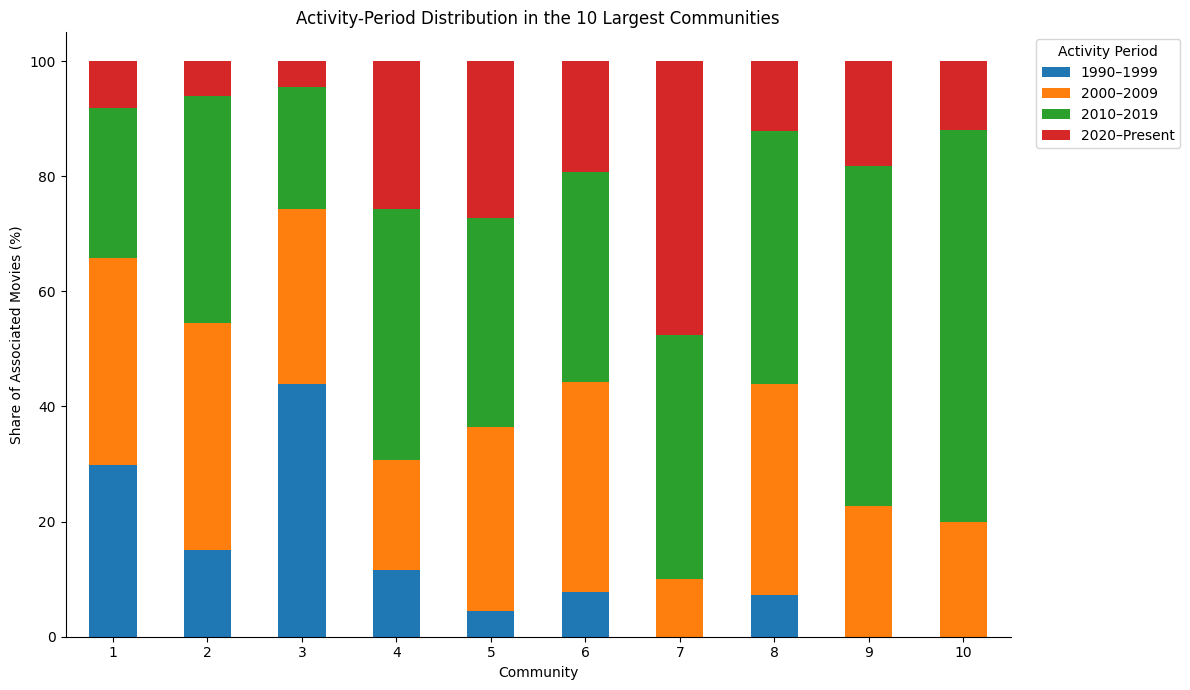

In [17]:
largest_ids = (
    community_summary_df
    .head(10)["Community"]
    .tolist()
)

activity_distribution = (
    community_movie_df[
        community_movie_df["community"].isin(
            largest_ids
        )
    ]
    .drop_duplicates(
        subset=[
            "community",
            "page_id"
        ]
    )
    .groupby(
        [
            "community",
            "activity_period"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

activity_share = (
    activity_distribution
    .div(
        activity_distribution.sum(
            axis=1
        ),
        axis=0
    )
    * 100
)

ax = activity_share.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

ax.set_title(
    "Activity-Period Distribution in the 10 Largest Communities"
)
ax.set_xlabel("Community")
ax.set_ylabel("Share of Associated Movies (%)")
ax.tick_params(
    axis="x",
    rotation=0
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(
    title="Activity Period",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


### 15. Cinematic Style Indicators

The dataset does not contain a direct cinematic-style field. Therefore, dominant genres and recurring directors are treated as indicators of cinematic tendencies rather than definitive style labels.

### 16. Demographic Characteristics

The collected dataset does not contain actor-level age, gender, birthplace, ethnicity, or background. A reliable demographic comparison cannot be performed without additional actor-level data. This is reported as a data limitation rather than inferred from names or other proxies.

### 17. Conclusions

In [18]:
print(
    f"1. {best_algorithm} was selected because it achieved the highest "
    f"weighted modularity ({best_result['modularity']:.4f})."
)

print(
    f"2. The selected partition contains {len(communities)} communities. "
    f"The largest community contains {len(communities[0])} actors."
)

print(
    "3. Community sizes are highly uneven: a small number of large communities "
    "coexist with many smaller collaboration groups."
)

largest_summary = (
    community_summary_df
    .iloc[0]
)

print(
    f"4. Community {int(largest_summary['Community'])} is the largest community "
    f"and is associated with {int(largest_summary['Associated Movies'])} movies "
    f"({largest_summary['Associated Movie Share (%)']:.2f}% of Period C movies)."
)

print(
    "5. Movies can contribute to more than one community when at least two cast "
    "members belong to each represented community, which better preserves "
    "cross-community collaboration patterns."
)

print(
    "6. Genres, recurring directors, and activity periods provide useful "
    "community-level characterization, while cinematic style is treated only "
    "as an indirect indicator."
)

print(
    "7. Demographic analysis was not performed because reliable actor-level "
    "demographic attributes are not available in the collected dataset."
)


1. Louvain was selected because it achieved the highest weighted modularity (0.4723).
2. The selected partition contains 85 communities. The largest community contains 297 actors.
3. Community sizes are highly uneven: a small number of large communities coexist with many smaller collaboration groups.
4. Community 1 is the largest community and is associated with 161 movies (18.42% of Period C movies).
5. Movies can contribute to more than one community when at least two cast members belong to each represented community, which better preserves cross-community collaboration patterns.
6. Genres, recurring directors, and activity periods provide useful community-level characterization, while cinematic style is treated only as an indirect indicator.
7. Demographic analysis was not performed because reliable actor-level demographic attributes are not available in the collected dataset.


### 18. Save Results

In [19]:
comparison_df.to_csv(
    "community_algorithm_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

community_sizes_df.to_csv(
    "community_sizes.csv",
    index=False,
    encoding="utf-8-sig"
)

central_actors_df.to_csv(
    "community_central_actors.csv",
    index=False,
    encoding="utf-8-sig"
)

community_summary_df.to_csv(
    "community_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

actor_community_df = pd.DataFrame({
    "actor": list(
        actor_to_community.keys()
    ),
    "community": list(
        actor_to_community.values()
    )
})

actor_community_df.to_csv(
    "actor_communities.csv",
    index=False,
    encoding="utf-8-sig"
)

metadata_quality_df.to_csv(
    "community_metadata_quality.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print("- community_algorithm_comparison.csv")
print("- community_sizes.csv")
print("- community_central_actors.csv")
print("- community_summary.csv")
print("- actor_communities.csv")
print("- community_metadata_quality.csv")

Saved:
- community_algorithm_comparison.csv
- community_sizes.csv
- community_central_actors.csv
- community_summary.csv
- actor_communities.csv
- community_metadata_quality.csv
